In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Load everything we saved from train_models.py
model = joblib.load("models/hybrid_xgboost_model.pkl")
scaler = joblib.load("models/hybrid_scaler.pkl")
label_encoder = joblib.load("models/label_encoder.pkl")
feature_list = joblib.load("models/hybrid_feature_list.pkl")

df = pd.read_csv("data/synthetic_students.csv")

print("Model loaded. Features:", feature_list)
print("Label classes:", label_encoder.classes_)

C:\Users\DELL\burnout-system\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded. Features: ['mbi_exhaustion', 'mbi_cynicism', 'mbi_efficacy', 'dass_depression', 'dass_anxiety', 'dass_stress', 'cope_score', 'attendance_rate', 'grade_decline_slope', 'assignment_completion_rate', 'late_submission_count', 'lms_login_frequency', 'time_on_task_weekly', 'engagement_variability']
Label classes: ['High' 'Low' 'Medium']


In [2]:
# Prepare the same scaled feature matrix the model was trained on
X = df[feature_list]
X_scaled = scaler.transform(X)

# TreeExplainer is the fast, exact method for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1800, 14, 3)


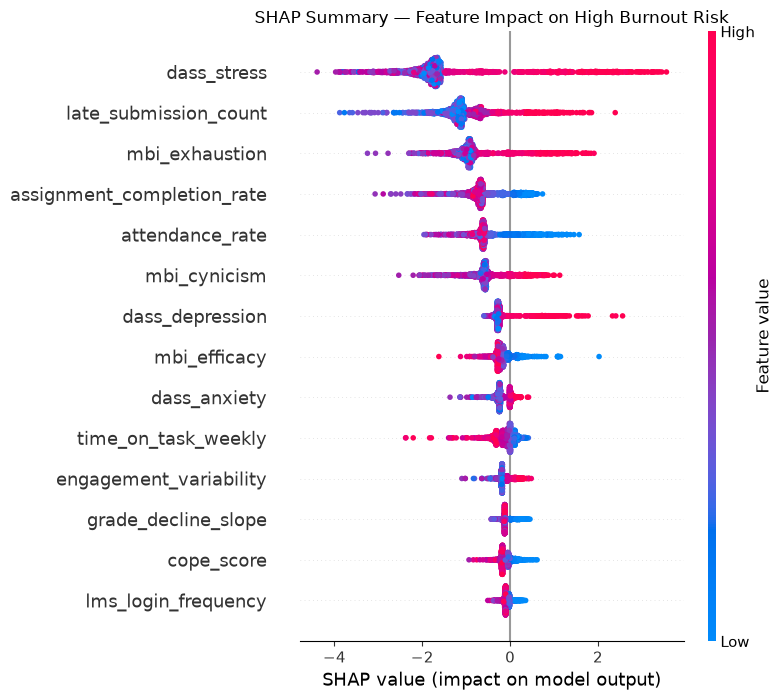

In [3]:
# We care most about explaining the "High" risk class (index 0, per label_encoder.classes_)
high_risk_idx = list(label_encoder.classes_).index("High")

shap.summary_plot(
    shap_values[:, :, high_risk_idx],
    X,
    feature_names=feature_list,
    show=False
)
plt.title("SHAP Summary — Feature Impact on High Burnout Risk")
plt.tight_layout()
plt.savefig("models/shap_summary_high_risk.png", dpi=150)
plt.show()

In [4]:
# Pick one student to explain individually (e.g. the first one)
student_idx = 0
student_id = df.iloc[student_idx]["student_id"]

# Get SHAP values for this student, for the High-risk class
student_shap = shap_values[student_idx, :, high_risk_idx]

# Build a clean ranked table: feature name + its SHAP contribution
explanation = pd.DataFrame({
    "feature": feature_list,
    "shap_value": student_shap
}).sort_values("shap_value", key=abs, ascending=False)

print(f"Student: {student_id}")
print(f"Actual risk level: {df.iloc[student_idx]['risk_level']}")
print("\nTop contributing factors (this is what the dashboard will show):")
print(explanation.head(5).to_string(index=False))

Student: S1000
Actual risk level: Medium

Top contributing factors (this is what the dashboard will show):
              feature  shap_value
          dass_stress   -2.013217
late_submission_count   -1.570773
       mbi_exhaustion   -1.120238
      attendance_rate   -0.518730
         mbi_cynicism   -0.430303


In [5]:
high_risk_students = df[df["risk_level"] == "High"].index
print(high_risk_students[:5].tolist())

[4, 37, 78, 113, 125]


In [6]:
student_idx = 4  # one of the High-risk students
student_id = df.iloc[student_idx]["student_id"]
student_shap = shap_values[student_idx, :, high_risk_idx]

explanation = pd.DataFrame({
    "feature": feature_list,
    "shap_value": student_shap
}).sort_values("shap_value", key=abs, ascending=False)

print(f"Student: {student_id}")
print(f"Actual risk level: {df.iloc[student_idx]['risk_level']}")
print("\nTop contributing factors:")
print(explanation.head(5).to_string(index=False))

Student: S1004
Actual risk level: High

Top contributing factors:
                   feature  shap_value
           dass_depression    2.559606
               dass_stress   -2.032035
            mbi_exhaustion    1.471564
           attendance_rate    1.295243
assignment_completion_rate    0.590066


In [7]:
def predict_with_explanation(student_features: dict, top_n: int = 5):
    """
    student_features: dict with all 14 hybrid feature names as keys
    Returns: risk_level, probabilities, top contributing factors
    """
    X_input = pd.DataFrame([student_features])[feature_list]
    X_input_scaled = scaler.transform(X_input)

    pred_class = model.predict(X_input_scaled)[0]
    pred_proba = model.predict_proba(X_input_scaled)[0]
    risk_level = label_encoder.inverse_transform([pred_class])[0]

    # SHAP values for this specific prediction, for the predicted class
    single_shap = explainer.shap_values(X_input_scaled)
    class_idx = list(label_encoder.classes_).index(risk_level)
    contributions = single_shap[0, :, class_idx]

    explanation_df = pd.DataFrame({
        "feature": feature_list,
        "shap_value": contributions
    }).sort_values("shap_value", key=abs, ascending=False).head(top_n)

    return {
        "risk_level": risk_level,
        "probabilities": dict(zip(label_encoder.classes_, pred_proba.round(3))),
        "top_factors": explanation_df.to_dict(orient="records")
    }

# Test it with student S1004 (the High-risk one)
test_input = df.iloc[4][feature_list].to_dict()
result = predict_with_explanation(test_input)
import json
print(json.dumps(result, indent=2, default=str))

{
  "risk_level": "High",
  "probabilities": {
    "High": "0.987",
    "Low": "0.0",
    "Medium": "0.013"
  },
  "top_factors": [
    {
      "feature": "dass_depression",
      "shap_value": 2.559605598449707
    },
    {
      "feature": "dass_stress",
      "shap_value": -2.0320348739624023
    },
    {
      "feature": "mbi_exhaustion",
      "shap_value": 1.4715638160705566
    },
    {
      "feature": "attendance_rate",
      "shap_value": 1.2952430248260498
    },
    {
      "feature": "assignment_completion_rate",
      "shap_value": 0.5900664925575256
    }
  ]
}
